<a href="https://colab.research.google.com/github/sachini86/MyResearch/blob/main/mergedataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running this cell, click the link,
# sign in to your Google account, copy the code, paste it here
print('Drive mounted!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted!


In [ ]:
# Install Kaggle API
!pip install -q kaggle

# Upload your kaggle.json API key
from google.colab import files
files.upload()  # ← click this, select your kaggle.json file

# Move it to the right place
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
!kaggle datasets download -d kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
!unzip -q cinnamon-quill-grades-classification-image-dataset.zip -d /content/kaggle_dataset

# Check what was downloaded
import os
for item in os.listdir('/content/kaggle_dataset'):
    print(item)

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kaveendahelitha40/cinnamon-quill-grades-classification-image-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 5.52G/5.52G [01:09<00:00, 85.1MB/s]

cinnamon quills images


In [ ]:
import os

# See what's inside
for root, dirs, files in os.walk('/content/kaggle_dataset'):
    level = root.replace('/content/kaggle_dataset', '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:  # only show 2 levels deep
        for f in files[:3]:  # show first 3 files as sample
            print(f'{indent}  {f}')

kaggle_dataset/
  cinnamon quills images/
    Alba/
    C5/
    C4/
    C5 Special/


In [ ]:
YOUR_DATA   = '/content/drive/MyDrive'
KAGGLE_DATA = '/content/kaggle_dataset/cinnamon quills images'

# IMPORTANT — match exact folder names including capitals
CLASSES_YOUR   = ['Alba', 'C4', 'C5', 'C5-special']      # your folder names
CLASSES_KAGGLE = ['Alba', 'C4', 'C5', 'C5 Special']       # kaggle folder names

WORK_DIR    = '/content/cinnamon_work'
MERGED_DATA = '/content/cinnamon_work/merged_dataset'
SPLIT_DATA  = '/content/cinnamon_work/split_dataset'

import os
os.makedirs(WORK_DIR, exist_ok=True)

# Verify counts
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = len([f for f in os.listdir(p1) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(p1) else 0
    c2 = len([f for f in os.listdir(p2) if f.lower().endswith(('.jpg','.jpeg','.png'))]) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:    0  kaggle:  173  total:  173
C4           → yours:    0  kaggle:  215  total:  215
C5           → yours:    0  kaggle:  199  total:  199
C5-special   → yours:    0  kaggle:  334  total:  334


In [ ]:
import os
import shutil

YOUR_DATA   = '/content/drive/MyDrive'
KAGGLE_DATA = '/content/kaggle_dataset/cinnamon quills images'

CLASSES_YOUR     = ['Alba', 'C4', 'C5', 'C5-special']
CLASSES_KAGGLE   = ['Alba', 'C4', 'C5', 'C5 Special']
CLASSES_STANDARD = ['alba', 'c4', 'c5', 'c5_special']

WORK_DIR    = '/content/cinnamon_work'
MERGED_DATA = '/content/cinnamon_work/merged_dataset'
SPLIT_DATA  = '/content/cinnamon_work/split_dataset'
os.makedirs(WORK_DIR, exist_ok=True)

def count_images_recursive(folder):
    """Counts all images in folder AND all subfolders"""
    count = 0
    for root, dirs, files in os.walk(folder):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp')):
                count += 1
    return count

# Verify counts
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [ ]:
for cls in ['C4', 'C5', 'C5-special']:
    path = f'/content/drive/MyDrive/{cls}'
    print(f'\n{cls} — exists: {os.path.exists(path)}')
    if os.path.exists(path):
        for item in os.listdir(path):
            print(f'  {item}')


C4 — exists: True
  Top
  Bottom
  Right
  Left
  Cross

C5 — exists: True
  Top
  Bottom
  Left
  Right
  Cross

C5-special — exists: True
  Top
  Bottom
  Right
  Left
  Cross


In [ ]:
import os

# Check Alba folder contents
alba_path = '/content/drive/MyDrive/Alba'
print('Exists:', os.path.exists(alba_path))
print('\nAll files inside:')
for f in os.listdir(alba_path):
    print(f)

Exists: True

All files inside:
Top
Left
Right
Bottom
Cross


In [ ]:
import os

for item in os.listdir('/content/drive/MyDrive'):
    if 'special' in item.lower() or 'C5' in item:
        print(repr(item))  # repr() shows hidden characters or spaces

'C5-special'
'C5'


In [ ]:
import os

for cls in ['C4', 'C5', 'C5-special']:
    path = f'/content/drive/MyDrive/{cls}'
    total = 0
    for subfolder in ['Top', 'Bottom', 'Left', 'Right', 'Cross']:
        sub_path = os.path.join(path, subfolder)
        if os.path.exists(sub_path):
            count = len([f for f in os.listdir(sub_path)
                        if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
            print(f'  {cls}/{subfolder} → {count} images')
            total += count
    print(f'  {cls} TOTAL → {total}\n')

  C4/Top → 19 images
  C4/Bottom → 19 images
  C4/Left → 19 images
  C4/Right → 19 images
  C4/Cross → 19 images
  C4 TOTAL → 95

  C5/Top → 23 images
  C5/Bottom → 23 images
  C5/Left → 23 images
  C5/Right → 23 images
  C5/Cross → 23 images
  C5 TOTAL → 115

  C5-special/Top → 32 images
  C5-special/Bottom → 32 images
  C5-special/Left → 32 images
  C5-special/Right → 32 images
  C5-special/Cross → 32 images
  C5-special TOTAL → 160



In [ ]:
# Check what's literally inside C4/Top
path = '/content/drive/MyDrive/C4/Top'
items = os.listdir(path)
print(f'Total items: {len(items)}')
print('First 10 items:')
for item in items[:10]:
    print(repr(item))

Total items: 38
First 10 items:
'C4_2.HEIC'
'C4_3.HEIC'
'C4_1.HEIC'
'C4_8.HEIC'
'C4_5.HEIC'
'C4_7.HEIC'
'C4_6.HEIC'
'C4_4.HEIC'
'C4_11.HEIC'
'C4_9.HEIC'


In [ ]:
# Install converter
!pip install -q pillow-heif

from pillow_heif import register_heif_opener
from PIL import Image
import os

register_heif_opener()

def convert_heic_to_jpg(base_path, classes):
    for cls in classes:
        cls_path = os.path.join(base_path, cls)
        if not os.path.exists(cls_path):
            continue
        converted = 0
        for root, dirs, files in os.walk(cls_path):
            for fname in files:
                if fname.upper().endswith('.HEIC'):
                    src = os.path.join(root, fname)
                    dst = src.replace('.HEIC', '.jpg').replace('.heic', '.jpg')
                    try:
                        img = Image.open(src)
                        img.save(dst, 'JPEG', quality=95)
                        converted += 1
                    except Exception as e:
                        print(f'  Failed: {fname} — {e}')
        print(f'{cls} → {converted} files converted')

convert_heic_to_jpg('/content/drive/MyDrive', ['C4', 'C5', 'C5-special'])
print('Done! Now re-run the count cell.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 71.6 MB/s eta 0:00:00
C4 → 95 files converted
C5 → 115 files converted
C5-special → 160 files converted
Done! Now re-run the count cell.


In [ ]:
for yours, kaggle in zip(CLASSES_YOUR, CLASSES_KAGGLE):
    p1 = os.path.join(YOUR_DATA, yours)
    p2 = os.path.join(KAGGLE_DATA, kaggle)
    c1 = count_images_recursive(p1) if os.path.exists(p1) else 0
    c2 = count_images_recursive(p2) if os.path.exists(p2) else 0
    print(f'{yours:12s} → yours: {c1:4d}  kaggle: {c2:4d}  total: {c1+c2:4d}')

Alba         → yours:  250  kaggle:  173  total:  423
C4           → yours:   95  kaggle:  215  total:  310
C5           → yours:  115  kaggle:  199  total:  314
C5-special   → yours:  160  kaggle:  334  total:  494


In [ ]:
!pip install -q scikit-learn matplotlib seaborn

import shutil, random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
#Merging both data

import shutil

MERGED_DATA = '/content/merged_dataset'
SPLIT_DATA  = '/content/split_dataset'
SAVE_DIR    = '/content/drive/MyDrive/cinnamon_results'
CLASSES     = ['alba', 'c4', 'c5', 'c5_special']

os.makedirs(SAVE_DIR, exist_ok=True)

# Map your folder names to clean class names
your_map   = {'alba': 'Alba', 'c4': 'C4', 'c5': 'C5', 'c5_special': 'C5-special'}
kaggle_map = {'alba': 'Alba', 'c4': 'C4', 'c5': 'C5', 'c5_special': 'C5-special'}
# ↑ adjust these if your Kaggle folder names differ

views = ['Top', 'Bottom', 'Left', 'Right', 'Cross']

print(f'{"Grade":<14} {"Yours":>6} {"Kaggle":>8} {"Total":>7}')
print('-' * 40)

for cls in CLASSES:
    out_dir = os.path.join(MERGED_DATA, cls)
    os.makedirs(out_dir, exist_ok=True)
    count = 0

    # Copy YOUR images (view subfolders)
    your_folder = f'/content/drive/MyDrive/{your_map[cls]}'
    your_count  = 0
    for view in views:
        vpath = os.path.join(your_folder, view)
        if not os.path.exists(vpath):
            continue
        for fname in os.listdir(vpath):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(vpath, fname),
                    os.path.join(out_dir, f'yours_{view}_{count:05d}_{fname}')
                )
                count += 1
                your_count += 1

    # Copy KAGGLE images (flat folder, no subfolders)
    kaggle_folder = os.path.join(KAGGLE_DATA, kaggle_map[cls])
    kaggle_count  = 0
    if os.path.exists(kaggle_folder):
        for fname in os.listdir(kaggle_folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(kaggle_folder, fname),
                    os.path.join(out_dir, f'kaggle_{count:05d}_{fname}')
                )
                count += 1
                kaggle_count += 1

    print(f'{cls:<14} {your_count:>6} {kaggle_count:>8} {count:>7}')

print('\n✅ Merge complete!')

Grade           Yours   Kaggle   Total
----------------------------------------
alba              250      173     423
c4                 95      215     310
c5                115      199     314
c5_special        160        0     160

✅ Merge complete!


In [ ]:
# New merging step

import shutil

MERGED_DATA = '/content/merged_dataset'
SPLIT_DATA  = '/content/split_dataset'
SAVE_DIR    = '/content/drive/MyDrive/cinnamon_results'
CLASSES     = ['alba', 'c4', 'c5', 'c5_special']

os.makedirs(SAVE_DIR, exist_ok=True)

your_map   = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5-special'   # hyphen — matches your Drive
}

kaggle_map = {
    'alba':       'Alba',
    'c4':         'C4',
    'c5':         'C5',
    'c5_special': 'C5 Special'   # space + capital S — matches Kaggle
}

views = ['Top', 'Bottom', 'Left', 'Right', 'Cross']

print(f'{"Grade":<14} {"Yours":>6} {"Kaggle":>8} {"Total":>7}')
print('-' * 40)

for cls in CLASSES:
    out_dir = os.path.join(MERGED_DATA, cls)
    os.makedirs(out_dir, exist_ok=True)
    count = 0

    # ── YOUR images (view subfolders) ──────────────────────────────
    your_folder = f'/content/drive/MyDrive/{your_map[cls]}'
    your_count  = 0
    for view in views:
        vpath = os.path.join(your_folder, view)
        if not os.path.exists(vpath):
            continue
        for fname in os.listdir(vpath):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(vpath, fname),
                    os.path.join(out_dir, f'yours_{view}_{count:05d}_{fname}')
                )
                count      += 1
                your_count += 1

    # ── KAGGLE images (flat folder) ────────────────────────────────
    kaggle_folder = os.path.join(KAGGLE_DATA, kaggle_map[cls])
    kaggle_count  = 0

    # ↓ debug print — remove after confirming it works
    print(f'  [debug] looking for kaggle folder: {kaggle_folder}  exists={os.path.exists(kaggle_folder)}')

    if os.path.exists(kaggle_folder):
        for fname in os.listdir(kaggle_folder):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                shutil.copy2(
                    os.path.join(kaggle_folder, fname),
                    os.path.join(out_dir, f'kaggle_{count:05d}_{fname}')
                )
                count        += 1
                kaggle_count += 1

    print(f'{cls:<14} {your_count:>6} {kaggle_count:>8} {count:>7}')

print('\n✅ Merge complete!')

Grade           Yours   Kaggle   Total
----------------------------------------
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/Alba  exists=True
alba              250      173     423
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C4  exists=True
c4                 95      215     310
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5  exists=True
c5                115      199     314
  [debug] looking for kaggle folder: /content/kaggle_dataset/cinnamon quills images/C5 Special  exists=True
c5_special        160      334     494

✅ Merge complete!


In [ ]:
# Cell split 70/15/15

import random

def split_dataset(merged_path, output_path, classes, train_r=0.70, val_r=0.15):
    random.seed(42)
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_path, split, cls), exist_ok=True)

    print(f'{"Grade":<14} {"Train":>6} {"Val":>6} {"Test":>6} {"Total":>7}')
    print('-' * 44)
    for cls in classes:
        src_dir = os.path.join(merged_path, cls)
        files   = [f for f in os.listdir(src_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png'))]
        random.shuffle(files)
        n       = len(files)
        n_train = int(n * train_r)
        n_val   = int(n * val_r)
        for split_name, flist in [('train', files[:n_train]),
                                   ('val',   files[n_train:n_train+n_val]),
                                   ('test',  files[n_train+n_val:])]:
            for fname in flist:
                shutil.copy2(
                    os.path.join(src_dir, fname),
                    os.path.join(output_path, split_name, cls, fname)
                )
        print(f'{cls:<14} {n_train:>6} {n_val:>6} {n-n_train-n_val:>6} {n:>7}')

split_dataset(MERGED_DATA, SPLIT_DATA, CLASSES)
print('\n✅ Split complete!')

Grade           Train    Val   Test   Total
--------------------------------------------
alba              296     63     64     423
c4                217     46     47     310
c5                219     47     48     314
c5_special        345     74     75     494

✅ Split complete!


Found 1077 images belonging to 4 classes.
Found 230 images belonging to 4 classes.
Found 234 images belonging to 4 classes.
Train: 1077  Val: 230  Test: 234
Classes: {'alba': 0, 'c4': 1, 'c5': 2, 'c5_special': 3}

Class weights:
  alba          : 0.910
  c4            : 1.241
  c5            : 1.229
  c5_special    : 0.780


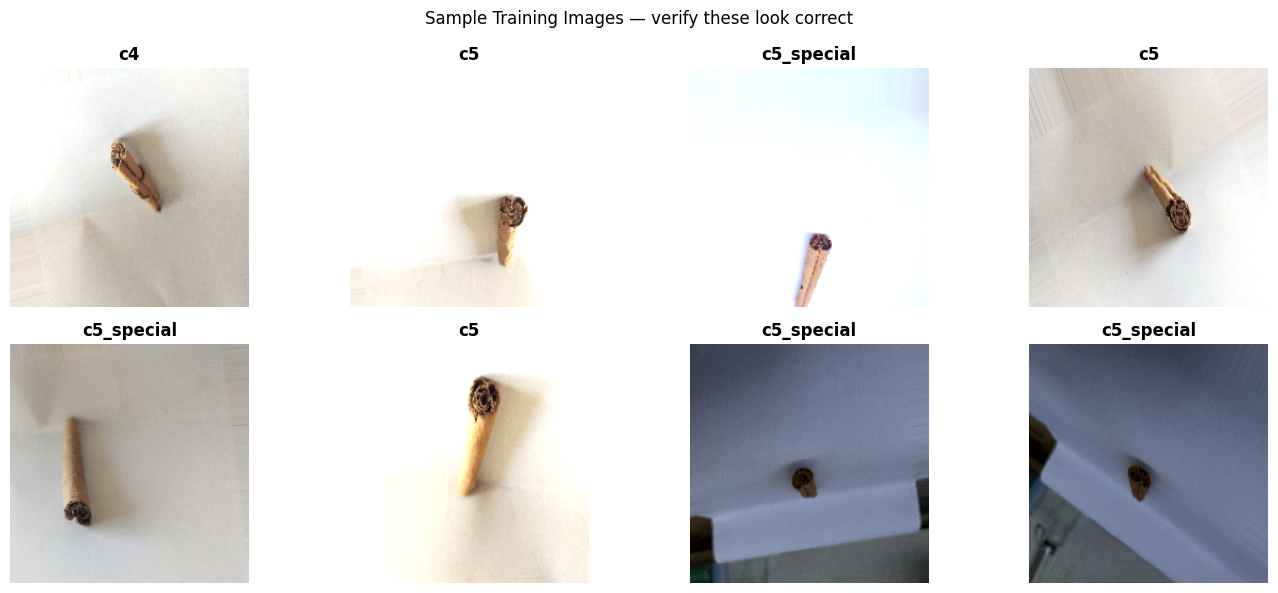

✅ Generators ready — check the images above look correct before training!


In [ ]:
# Generators + class weights:

import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_gen    = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.7, 1.3],
    channel_shift_range=20.0,
    fill_mode='nearest'
)
val_test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=True, seed=42
)
val_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)
test_data = val_test_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'),
    target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    classes=CLASSES, class_mode='categorical',
    shuffle=False
)

cw_array     = compute_class_weight('balanced',
                   classes=np.unique(train_data.classes),
                   y=train_data.classes)
class_weights = dict(enumerate(cw_array))

print(f'Train: {train_data.samples}  Val: {val_data.samples}  Test: {test_data.samples}')
print(f'Classes: {train_data.class_indices}')
print('\nClass weights:')
for i, cls in enumerate(CLASSES):
    print(f'  {cls:<14}: {cw_array[i]:.3f}')

# Sanity check — show sample images
imgs, lbls = next(iter(train_data))
fig, axes  = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    ax.set_title(CLASSES[np.argmax(lbls[i])], fontweight='bold')
    ax.axis('off')
plt.suptitle('Sample Training Images — verify these look correct', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=100)
plt.show()
print('✅ Generators ready — check the images above look correct before training!')

In [ ]:
# Run the MobileNetV2 training

from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ── MobileNetV2 ───────────────────────────────────────────────
base_mobile = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_mobile.trainable = False

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_mobile(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)
mobilenet = models.Model(inputs, outputs)

callbacks_mob = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/best_mobilenet.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('--- Phase 1: Training head (5 epochs) ---')
mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
h1 = mobilenet.fit(train_data, epochs=5, validation_data=val_data,
                   class_weight=class_weights, callbacks=callbacks_mob)

print('\n--- Phase 2: Fine-tuning top 40% of layers ---')
base_mobile.trainable = True
fine_tune_from = int(len(base_mobile.layers) * 0.6)
for layer in base_mobile.layers[:fine_tune_from]:
    layer.trainable = False

mobilenet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
h2 = mobilenet.fit(train_data, epochs=25, validation_data=val_data,
                   class_weight=class_weights, callbacks=callbacks_mob)

print('\n✅ MobileNetV2 training complete!')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Phase 1: Training head (5 epochs) ---
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.3588 - loss: 1.6603
Epoch 1: val_accuracy improved from None to 0.59130, saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 326s 9s/step - accuracy: 0.4578 - loss: 1.4320 - val_accuracy: 0.5913 - val_loss: 0.9064 - learning_rate: 0.0010
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5863 - loss: 1.0494
Epoch 2: val_accuracy improved from 0.59130 to 0.69130, saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 267s 8s/step - accuracy: 0.5915 - loss: 1.0184 - val_accuracy: 0.6913 - val_loss: 0.7878 - learning_rate: 0.0010
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6363 - loss: 0.9061
Epoch 3: val_accuracy improved from 0.69130 to 0.70435, saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 279s 8s/step - accuracy: 0.6267 - loss: 0.8778 - val_accuracy: 0.7043 - val_loss: 0.6974 - learning_rate: 0.0010
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6528 - loss: 0.8741
Epoch 4: val_accuracy did not improve from 0.70435
34/34 ━━━━━━━━━━━━━━━━━━━━ 260s 8s/step - accuracy: 0.6602 - loss: 0.8517 - val_accuracy: 0.6913 - val_loss: 0.6906 - learning_rate: 0.0010
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7035 - loss: 0.7342
Epoch 5: val_accuracy improved from 0.70435 to 0.73913, saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 267s 8s/step - accuracy: 0.7047 - loss: 0.7230 - val_accuracy: 0.7391 - val_loss: 0.6421 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 5.

--- Phase 2: Fine-tuning top 40% of layers ---
Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5180 - loss: 1.1201
Epoch 1: val_accuracy did not improve from 0.73913
34/34 ━━━━━━━━━━━━━━━━━━━━ 311s 8s/step - accuracy: 0.5153 - loss: 1.1330 - val_accuracy: 0.7348 - val_loss: 0.5867 - learning_rate: 1.0000e-05
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5557 - loss: 1.0719
Epoch 2: val_accuracy did not improve from 0.73913
34/34 ━━━━━━━━━━━━━━━━━━━━ 263s 8s/step - accuracy: 0.5636 - loss: 1.0452 - val_accuracy: 0.7348 - val_loss: 0.5460 - learning_rate: 1.0000e-05
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6156 - loss: 0.9780
Epoch 3: val_accuracy


Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_mobilenet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 268s 8s/step - accuracy: 0.6017 - loss: 0.9850 - val_accuracy: 0.7435 - val_loss: 0.5371 - learning_rate: 1.0000e-05
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6197 - loss: 0.9151
Epoch 4: val_accuracy did not improve from 0.74348
34/34 ━━━━━━━━━━━━━━━━━━━━ 361s 9s/step - accuracy: 0.6249 - loss: 0.8716 - val_accuracy: 0.7391 - val_loss: 0.5459 - learning_rate: 1.0000e-05
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6321 - loss: 0.8660
Epoch 5: val_accuracy did not improve from 0.74348
34/34 ━━━━━━━━━━━━━━━━━━━━ 300s 9s/step - accuracy: 0.6332 - loss: 0.8768 - val_accuracy: 0.7304 - val_loss: 0.5622 - learning_rate: 1.0000e-05
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6429 - loss: 0.8679
Epoch 6: val_accuracy did not improve from 0.74348
34/34 ━━━━━━━━━━━━━━━━━━━━ 278s 8s/step - accuracy: 0.6500 - loss: 0.8267

8/8 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step
=== MobileNetV2 Test Results ===
              precision    recall  f1-score   support

        alba     0.9630    0.8125    0.8814        64
          c4     0.6786    0.8085    0.7379        47
          c5     0.6471    0.2292    0.3385        48
  c5_special     0.6542    0.9333    0.7692        75

    accuracy                         0.7308       234
   macro avg     0.7357    0.6959    0.6817       234
weighted avg     0.7421    0.7308    0.7052       234



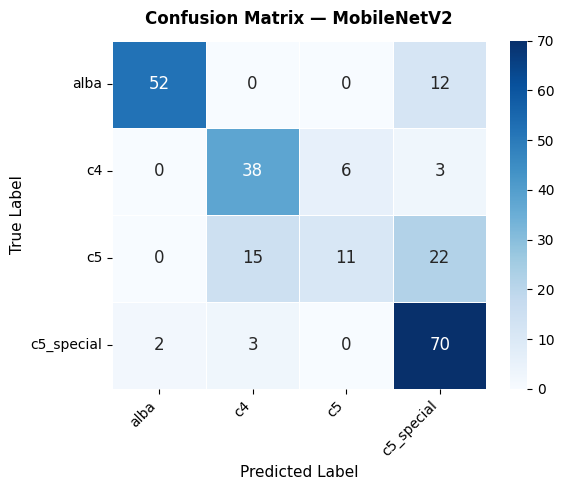

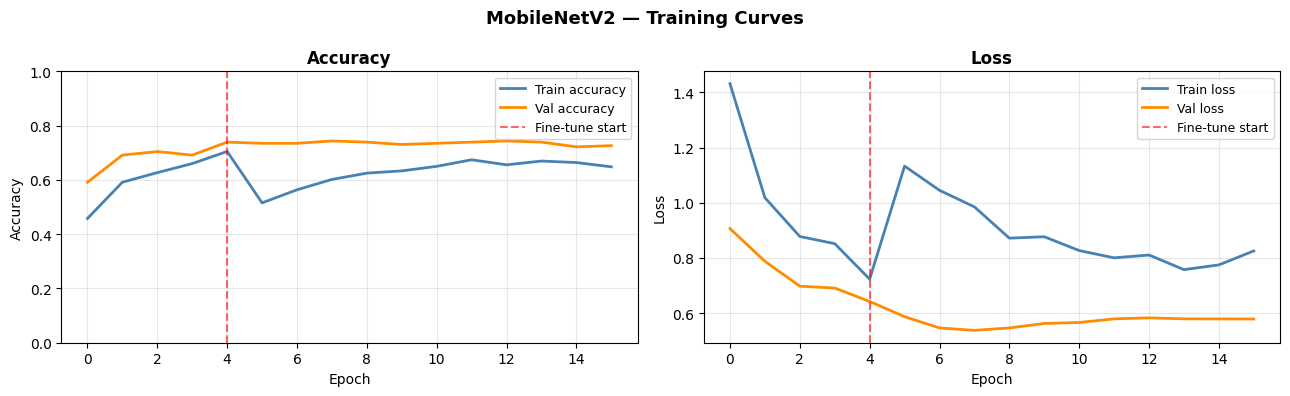

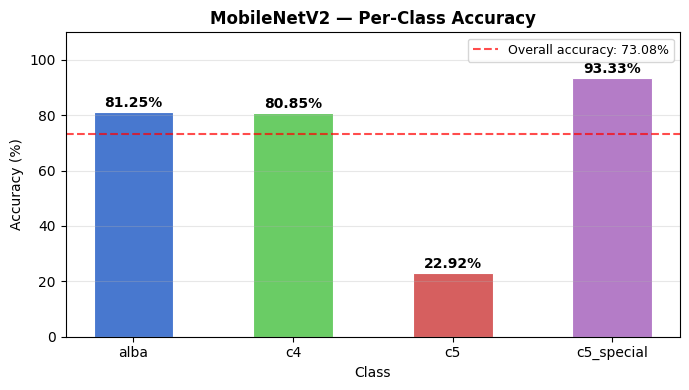


 Overall Accuracy : 73.08%  (0.7308)


In [ ]:
# ── Evaluate MobileNetV2 ──────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

test_data.reset()
y_pred_mob = np.argmax(mobilenet.predict(test_data), axis=1)
y_true     = test_data.classes
labels     = list(test_data.class_indices.keys())

# ── 1. Classification Report (exact DenseNet style) ──────────
print('=== MobileNetV2 Test Results ===')
print(classification_report(y_true, y_pred_mob, target_names=labels, digits=4))

# ── 2. Confusion Matrix Plot ──────────────────────────────────
cm = confusion_matrix(y_true, y_pred_mob)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 12})
plt.title('Confusion Matrix — MobileNetV2', fontweight='bold', pad=12)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_mobilenet.png', dpi=150)
plt.show()

# ── 3. Training Curve Plot ────────────────────────────────────
acc     = h1.history['accuracy']     + h2.history['accuracy']
val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
loss    = h1.history['loss']         + h2.history['loss']
val_loss= h1.history['val_loss']     + h2.history['val_loss']
ft_start = len(h1.history['accuracy'])   # fine-tune epoch marker

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('MobileNetV2 — Training Curves', fontweight='bold', fontsize=13)

# Accuracy subplot
axes[0].plot(acc,     label='Train accuracy', color='steelblue',  linewidth=2)
axes[0].plot(val_acc, label='Val accuracy',   color='darkorange', linewidth=2)
axes[0].axvline(x=ft_start - 1, color='red', linestyle='--',
                alpha=0.6, label='Fine-tune start')
axes[0].set_title('Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_ylim([0, 1])

# Loss subplot
axes[1].plot(loss,     label='Train loss', color='steelblue',  linewidth=2)
axes[1].plot(val_loss, label='Val loss',   color='darkorange', linewidth=2)
axes[1].axvline(x=ft_start - 1, color='red', linestyle='--',
                alpha=0.6, label='Fine-tune start')
axes[1].set_title('Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/curve_mobilenet.png', dpi=150)
plt.show()

# ── 4. Per-class Accuracy Bar Chart ──────────────────────────
per_class_acc = []
for i in range(len(labels)):
    mask = y_true == i
    per_class_acc.append(np.mean(y_pred_mob[mask] == y_true[mask]))

overall_acc = np.mean(y_pred_mob == y_true)

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#4878CF', '#6ACC65', '#D65F5F', '#B47CC7']
bars = ax.bar(labels, [a * 100 for a in per_class_acc],
              color=colors, width=0.5, edgecolor='white', linewidth=0.8)

# Value labels on bars
for bar, a in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{a*100:.2f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.axhline(y=overall_acc * 100, color='red', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label=f'Overall accuracy: {overall_acc*100:.2f}%')
ax.set_title('MobileNetV2 — Per-Class Accuracy', fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Class')
ax.set_ylim([0, 110])
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/perclass_mobilenet.png', dpi=150)
plt.show()

print(f'\n Overall Accuracy : {overall_acc*100:.2f}%  ({overall_acc:.4f})')

In [ ]:
# ── EfficientNetB0 ───────────────────────────────────────────
base_eff = EfficientNetB0(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_eff.trainable = False

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_eff(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)
efficientnet = models.Model(inputs, outputs)

callbacks_eff = [
    EarlyStopping(monitor='val_accuracy', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=4, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/best_efficientnet.h5',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('--- Phase 1: Training head (5 epochs) ---')
efficientnet.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                     loss='categorical_crossentropy', metrics=['accuracy'])
h3 = efficientnet.fit(train_data, epochs=5, validation_data=val_data,
                      class_weight=class_weights, callbacks=callbacks_eff)

print('\n--- Phase 2: Fine-tuning top 40% of layers ---')
base_eff.trainable = True
fine_tune_from = int(len(base_eff.layers) * 0.6)
for layer in base_eff.layers[:fine_tune_from]:
    layer.trainable = False

efficientnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                     loss='categorical_crossentropy', metrics=['accuracy'])
h4 = efficientnet.fit(train_data, epochs=25, validation_data=val_data,
                      class_weight=class_weights, callbacks=callbacks_eff)

print('\n✅ EfficientNetB0 training complete!')

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- Phase 1: Training head (5 epochs) ---
Epoch 1/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2720 - loss: 1.7365
Epoch 1: val_accuracy improved from None to 0.20000, saving model to /content/drive/MyDrive/cinnamon_results/best_efficientnet.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_efficientnet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 326s 9s/step - accuracy: 0.2711 - loss: 1.7729 - val_accuracy: 0.2000 - val_loss: 1.4078 - learning_rate: 0.0010
Epoch 2/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.3020 - loss: 1.6744
Epoch 2: val_accuracy did not improve from 0.20000
34/34 ━━━━━━━━━━━━━━━━━━━━ 276s 8s/step - accuracy: 0.2721 - loss: 1.6988 - val_accuracy: 0.2000 - val_loss: 1.4004 - learning_rate: 0.0010
Epoch 3/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2520 - loss: 1.7188
Epoch 3: val_accuracy did not improve from 0.20000
34/34 ━━━━━━━━━━━━━━━━━━━━ 263s 8s/step - accuracy: 0.2516 - loss: 1.6442 - val_accuracy: 0.2000 - val_loss: 1.3878 - learning_rate: 0.0010
Epoch 4/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2378 - loss: 1.5506
Epoch 4: val_accuracy improved from 0.20000 to 0.32174, saving model to /content/drive/MyDrive/cinnamon_results/best_efficientnet.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_efficientnet.h5
34/34 ━━━━━━━━━━━━━━━━━━━━ 266s 8s/step - accuracy: 0.2312 - loss: 1.5576 - val_accuracy: 0.3217 - val_loss: 1.3819 - learning_rate: 0.0010
Epoch 5/5
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.2656 - loss: 1.5034
Epoch 5: val_accuracy did not improve from 0.32174
34/34 ━━━━━━━━━━━━━━━━━━━━ 257s 8s/step - accuracy: 0.2600 - loss: 1.5169 - val_accuracy: 0.2000 - val_loss: 1.3890 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 4.

--- Phase 2: Fine-tuning top 40% of layers ---
Epoch 1/25
 9/34 ━━━━━━━━━━━━━━━━━━━━ 2:19 6s/step - accuracy: 0.2471 - loss: 1.5745

In [ ]:
# ── Evaluate EfficientNetB0 ───────────────────────────────────
test_data.reset()
y_pred_eff = np.argmax(efficientnet.predict(test_data), axis=1)
labels     = list(test_data.class_indices.keys())

print('=== EfficientNetB0 Results ===')
print(classification_report(test_data.classes, y_pred_eff, target_names=labels, digits=4))

# Confusion matrix
cm = confusion_matrix(test_data.classes, y_pred_eff)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix — EfficientNetB0', fontweight='bold')
plt.ylabel('True label'); plt.xlabel('Predicted label')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/cm_efficientnet.png', dpi=150)
plt.show()

# Training curve
acc = h3.history['accuracy']     + h4.history['accuracy']
val = h3.history['val_accuracy'] + h4.history['val_accuracy']
plt.figure(figsize=(9, 4))
plt.plot(acc, label='Train accuracy', color='steelblue')
plt.plot(val, label='Val accuracy',   color='orange')
plt.axvline(x=len(h3.history['accuracy'])-1,
            color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
plt.title('EfficientNetB0 — Training Curve', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/curve_efficientnet.png', dpi=150)
plt.show()

# Final comparison
test_data.reset()
acc_mob = accuracy_score(test_data.classes,
                          np.argmax(mobilenet.predict(test_data), axis=1))
test_data.reset()
acc_eff = accuracy_score(test_data.classes,
                          np.argmax(efficientnet.predict(test_data), axis=1))

print('\n' + '='*45)
print('  FINAL COMPARISON')
print('='*45)
print(f'  MobileNetV2    : {acc_mob*100:.2f}%')
print(f'  EfficientNetB0 : {acc_eff*100:.2f}%')
print(f'  Best model     : {"EfficientNetB0" if acc_eff >= acc_mob else "MobileNetV2"}')
print('='*45)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q pillow-heif scikit-learn matplotlib seaborn

import os, shutil, random, gc
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import (MobileNetV2, DenseNet121,
                                           ResNet50V2, MobileNetV3Small, InceptionV3)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print('✅ TensorFlow:', tf.__version__)
print('✅ GPU:', tf.config.list_physical_devices('GPU'))

In [ ]:
# ── Train and Evaluate Multiple Models ────────────────────────
from tensorflow.keras.applications import DenseNet121, ResNet50V2, MobileNetV3Small, InceptionV3
from sklearn.metrics import accuracy_score
import gc

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
results    = {}  # stores all results for final comparison

def build_model(base_fn, name, input_shape=(*IMG_SIZE, 3)):
    base          = base_fn(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False
    inputs  = tf.keras.Input(shape=input_shape)
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.BatchNormalization()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.Dropout(0.4)(x)
    outputs = layers.Dense(4, activation='softmax')(x)
    model   = models.Model(inputs, outputs)
    print(f'✅ {name} built — {model.count_params():,} parameters')
    return model, base

def train_model(model, base, name, phase1_epochs=10, phase2_epochs=20, finetune_pct=0.4):
    cb = [
        EarlyStopping(monitor='val_accuracy', patience=8,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=4, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'{SAVE_DIR}/best_{name}.h5',
                        monitor='val_accuracy', save_best_only=True, verbose=1)
    ]

    # Phase 1 — head only
    print(f'\n{"="*50}')
    print(f'TRAINING: {name}')
    print(f'{"="*50}')
    print(f'--- Phase 1: Training head ({phase1_epochs} epochs) ---')
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h1 = model.fit(train_data, epochs=phase1_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)

    best_p1 = max(h1.history['val_accuracy'])
    print(f'\nBest val accuracy after Phase 1: {best_p1:.4f}')

    # Phase 2 — fine-tune
    print(f'\n--- Phase 2: Fine-tuning top {int(finetune_pct*100)}% layers ---')
    base.trainable = True
    freeze_until  = int(len(base.layers) * (1 - finetune_pct))
    for layer in base.layers[:freeze_until]:
        layer.trainable = False

    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    h2 = model.fit(train_data, epochs=phase2_epochs,
                   validation_data=val_data,
                   class_weight=class_weights, callbacks=cb, verbose=1)

    return h1, h2

def evaluate_model(model, name, h1, h2):
    # Test set evaluation
    test_data.reset()
    y_pred = np.argmax(model.predict(test_data, verbose=0), axis=1)
    y_true = test_data.classes
    labels = list(test_data.class_indices.keys())
    acc    = accuracy_score(y_true, y_pred)

    print(f'\n=== {name} Test Results ===')
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('True label'); plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/cm_{name}.png', dpi=150)
    plt.show()

    # Training curve
    acc_curve = h1.history['accuracy']     + h2.history['accuracy']
    val_curve = h1.history['val_accuracy'] + h2.history['val_accuracy']
    plt.figure(figsize=(9, 4))
    plt.plot(acc_curve, label='Train accuracy', color='steelblue')
    plt.plot(val_curve, label='Val accuracy',   color='orange')
    plt.axvline(x=len(h1.history['accuracy'])-1,
                color='red', linestyle='--', alpha=0.6, label='Fine-tune start')
    plt.title(f'{name} — Training Curve', fontweight='bold')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{SAVE_DIR}/curve_{name}.png', dpi=150)
    plt.show()

    # Store results
    results[name] = {
        'accuracy':  acc,
        'report':    classification_report(y_true, y_pred,
                         target_names=labels, digits=4, output_dict=True)
    }
    print(f'✅ {name} — Test Accuracy: {acc*100:.2f}%')
    return acc

# ── Store MobileNetV2 result we already have ──────────────────
test_data.reset()
mob_acc = accuracy_score(test_data.classes,
                          np.argmax(mobilenet.predict(test_data, verbose=0), axis=1))
results['MobileNetV2'] = {'accuracy': mob_acc}
print(f'MobileNetV2 already trained — Test Accuracy: {mob_acc*100:.2f}%')

# ── DenseNet121 ───────────────────────────────────────────────
dn_model, dn_base = build_model(DenseNet121, 'DenseNet121')
dn_h1, dn_h2      = train_model(dn_model, dn_base, 'DenseNet121')
evaluate_model(dn_model, 'DenseNet121', dn_h1, dn_h2)

# Free memory before next model
del dn_model, dn_base
gc.collect()
tf.keras.backend.clear_session()

# ── ResNet50V2 ────────────────────────────────────────────────
rn_model, rn_base = build_model(ResNet50V2, 'ResNet50V2')
rn_h1, rn_h2      = train_model(rn_model, rn_base, 'ResNet50V2')
evaluate_model(rn_model, 'ResNet50V2', rn_h1, rn_h2)

del rn_model, rn_base
gc.collect()
tf.keras.backend.clear_session()

# ── MobileNetV3Small ──────────────────────────────────────────
mv3_model, mv3_base = build_model(MobileNetV3Small, 'MobileNetV3Small')
mv3_h1, mv3_h2      = train_model(mv3_model, mv3_base, 'MobileNetV3Small')
evaluate_model(mv3_model, 'MobileNetV3Small', mv3_h1, mv3_h2)

del mv3_model, mv3_base
gc.collect()
tf.keras.backend.clear_session()

# ── InceptionV3 (needs 299x299) ───────────────────────────────
# Rebuild generators at 299x299 for InceptionV3
inc_gen      = ImageDataGenerator(
    rescale=1./255, rotation_range=30, width_shift_range=0.15,
    height_shift_range=0.15, shear_range=0.1, zoom_range=0.2,
    horizontal_flip=True, vertical_flip=True,
    brightness_range=[0.7, 1.3], fill_mode='nearest'
)
inc_val_gen  = ImageDataGenerator(rescale=1./255)

train_data_inc = inc_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'train'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=True, seed=42
)
val_data_inc = inc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'val'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)
test_data_inc = inc_val_gen.flow_from_directory(
    os.path.join(SPLIT_DATA, 'test'), target_size=(299,299),
    batch_size=BATCH_SIZE, classes=CLASSES,
    class_mode='categorical', shuffle=False
)

# Temporarily swap generators
_train, _val, _test = train_data, val_data, test_data
train_data, val_data, test_data = train_data_inc, val_data_inc, test_data_inc

from tensorflow.keras.applications import InceptionV3
inc_model, inc_base = build_model(InceptionV3, 'InceptionV3', input_shape=(299,299,3))
inc_h1, inc_h2      = train_model(inc_model, inc_base, 'InceptionV3')
evaluate_model(inc_model, 'InceptionV3', inc_h1, inc_h2)

# Restore original generators
train_data, val_data, test_data = _train, _val, _test
del inc_model, inc_base
gc.collect()
tf.keras.backend.clear_session()

MobileNetV2 already trained — Test Accuracy: 73.22%
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
✅ DenseNet121 built — 7,305,028 parameters

TRAINING: DenseNet121
--- Phase 1: Training head (10 epochs) ---
Epoch 1/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4895 - loss: 1.2348
Epoch 1: val_accuracy improved from None to 0.46111, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 257s 8s/step - accuracy: 0.6007 - loss: 0.9520 - val_accuracy: 0.4611 - val_loss: 1.1810 - learning_rate: 0.0010
Epoch 2/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7447 - loss: 0.6009
Epoch 2: val_accuracy improved from 0.46111 to 0.60556, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 2: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.7595 - loss: 0.5690 - val_accuracy: 0.6056 - val_loss: 0.8703 - learning_rate: 0.0010
Epoch 3/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8186 - loss: 0.4677
Epoch 3: val_accuracy improved from 0.60556 to 0.69444, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 3: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 178s 7s/step - accuracy: 0.8069 - loss: 0.4738 - val_accuracy: 0.6944 - val_loss: 0.6671 - learning_rate: 0.0010
Epoch 4/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8066 - loss: 0.4474
Epoch 4: val_accuracy improved from 0.69444 to 0.70000, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 179s 7s/step - accuracy: 0.8258 - loss: 0.4221 - val_accuracy: 0.7000 - val_loss: 0.6745 - learning_rate: 0.0010
Epoch 5/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8727 - loss: 0.3246
Epoch 5: val_accuracy improved from 0.70000 to 0.73333, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5


...


Epoch 8: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 174s 6s/step - accuracy: 0.8637 - loss: 0.3521 - val_accuracy: 0.8167 - val_loss: 0.4326 - learning_rate: 0.0010
Epoch 9/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8735 - loss: 0.3048
Epoch 9: val_accuracy did not improve from 0.81667
27/27 ━━━━━━━━━━━━━━━━━━━━ 179s 7s/step - accuracy: 0.8863 - loss: 0.2844 - val_accuracy: 0.7556 - val_loss: 0.4522 - learning_rate: 0.0010
Epoch 10/10
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8974 - loss: 0.2633
Epoch 10: val_accuracy did not improve from 0.81667
27/27 ━━━━━━━━━━━━━━━━━━━━ 176s 7s/step - accuracy: 0.8910 - loss: 0.2895 - val_accuracy: 0.7944 - val_loss: 0.4811 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 8.

Best val accuracy after Phase 1: 0.8167

--- Phase 2: Fine-tuning top 40% layers ---
Epoch 1/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7966 - 


Epoch 1: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 348s 10s/step - accuracy: 0.8199 - loss: 0.4491 - val_accuracy: 0.8611 - val_loss: 0.3496 - learning_rate: 1.0000e-05
Epoch 2/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8238 - loss: 0.4256
Epoch 2: val_accuracy did not improve from 0.86111
27/27 ━━━━━━━━━━━━━━━━━━━━ 174s 6s/step - accuracy: 0.8246 - loss: 0.4122 - val_accuracy: 0.8611 - val_loss: 0.3247 - learning_rate: 1.0000e-05
Epoch 3/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8740 - loss: 0.3091
Epoch 3: val_accuracy did not improve from 0.86111
27/27 ━━━━━━━━━━━━━━━━━━━━ 192s 7s/step - accuracy: 0.8566 - loss: 0.3285 - val_accuracy: 0.8556 - val_loss: 0.3185 - learning_rate: 1.0000e-05
Epoch 4/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8339 - loss: 0.3936
Epoch 4: val_accuracy improved from 0.86111 to 0.86667, saving model to /content/drive/MyDrive/cinnamon_results/best_Dens


Epoch 4: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 199s 7s/step - accuracy: 0.8495 - loss: 0.3629 - val_accuracy: 0.8667 - val_loss: 0.3065 - learning_rate: 1.0000e-05
Epoch 5/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8461 - loss: 0.3635
Epoch 5: val_accuracy improved from 0.86667 to 0.87222, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 5: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 180s 7s/step - accuracy: 0.8448 - loss: 0.3635 - val_accuracy: 0.8722 - val_loss: 0.3159 - learning_rate: 1.0000e-05
Epoch 6/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8665 - loss: 0.3136
Epoch 6: val_accuracy improved from 0.87222 to 0.87778, saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5



Epoch 6: finished saving model to /content/drive/MyDrive/cinnamon_results/best_DenseNet121.h5
27/27 ━━━━━━━━━━━━━━━━━━━━ 175s 7s/step - accuracy: 0.8756 - loss: 0.3166 - val_accuracy: 0.8778 - val_loss: 0.3060 - learning_rate: 1.0000e-05
Epoch 7/20
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8757 - loss: 0.2970